Evaluate one already-frozen checkpoint against the three expert-agreement splits.

In [5]:
import os
from pathlib import Path

from ai4mars import acquire_frozen_checkpoint, run_sealed_expert_evaluation

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

configured_dataset = os.environ.get('AI4MARS_DATASET_ROOT')
if configured_dataset:
    DATASET_ROOT = Path(configured_dataset)
else:
    local_dataset = PROJECT_ROOT / 'data' / 'raw' / 'ai4mars' / 'ai4mars-dataset-merged-0.6'
    matches = [local_dataset] if local_dataset.is_dir() else list(Path('/kaggle/input').glob('**/ai4mars-dataset-merged-0.6'))
    if len(matches) != 1:
        raise RuntimeError('Set AI4MARS_DATASET_ROOT to the extracted AI4Mars merged 0.6 directory.')
    DATASET_ROOT = matches[0]

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'reproduction' / 'paper_deeplabv3plus_kaggle_p100.yaml'
MANIFEST_ROOT = PROJECT_ROOT / 'artifacts' / 'manifests'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'expert-evaluation'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'ai4mars-paper-reproduction' / 'frozen' / 'deeplabv3plus-tesla-p100-seed42-best-val-miou.pth'
checkpoint = acquire_frozen_checkpoint(CHECKPOINT_PATH)
print('Frozen checkpoint verified')
print(f'  Path: {checkpoint.path}')
print(f'  Epoch: {checkpoint.epoch}')
print(f'  SHA-256: {checkpoint.sha256}')

Frozen checkpoint verified
  Path: c:\Users\Jacob\AI4Mars\artifacts\ai4mars-paper-reproduction\frozen\deeplabv3plus-tesla-p100-seed42-best-val-miou.pth
  Epoch: 25
  SHA-256: 90e74a9071d9bfb180d80ab2bb1927f1ea83a74d7e0601750873c2547a5ddaa3


In [2]:
run_dir = run_sealed_expert_evaluation(
    config_path=CONFIG_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    dataset_root=DATASET_ROOT,
    manifest_root=MANIFEST_ROOT,
    output_root=OUTPUT_ROOT,
    device='auto',
)
print(f'Completed sealed evaluation: {run_dir}')

Completed sealed evaluation: c:\Users\Jacob\AI4Mars\outputs\expert-evaluation\runs\ai4mars-baseline


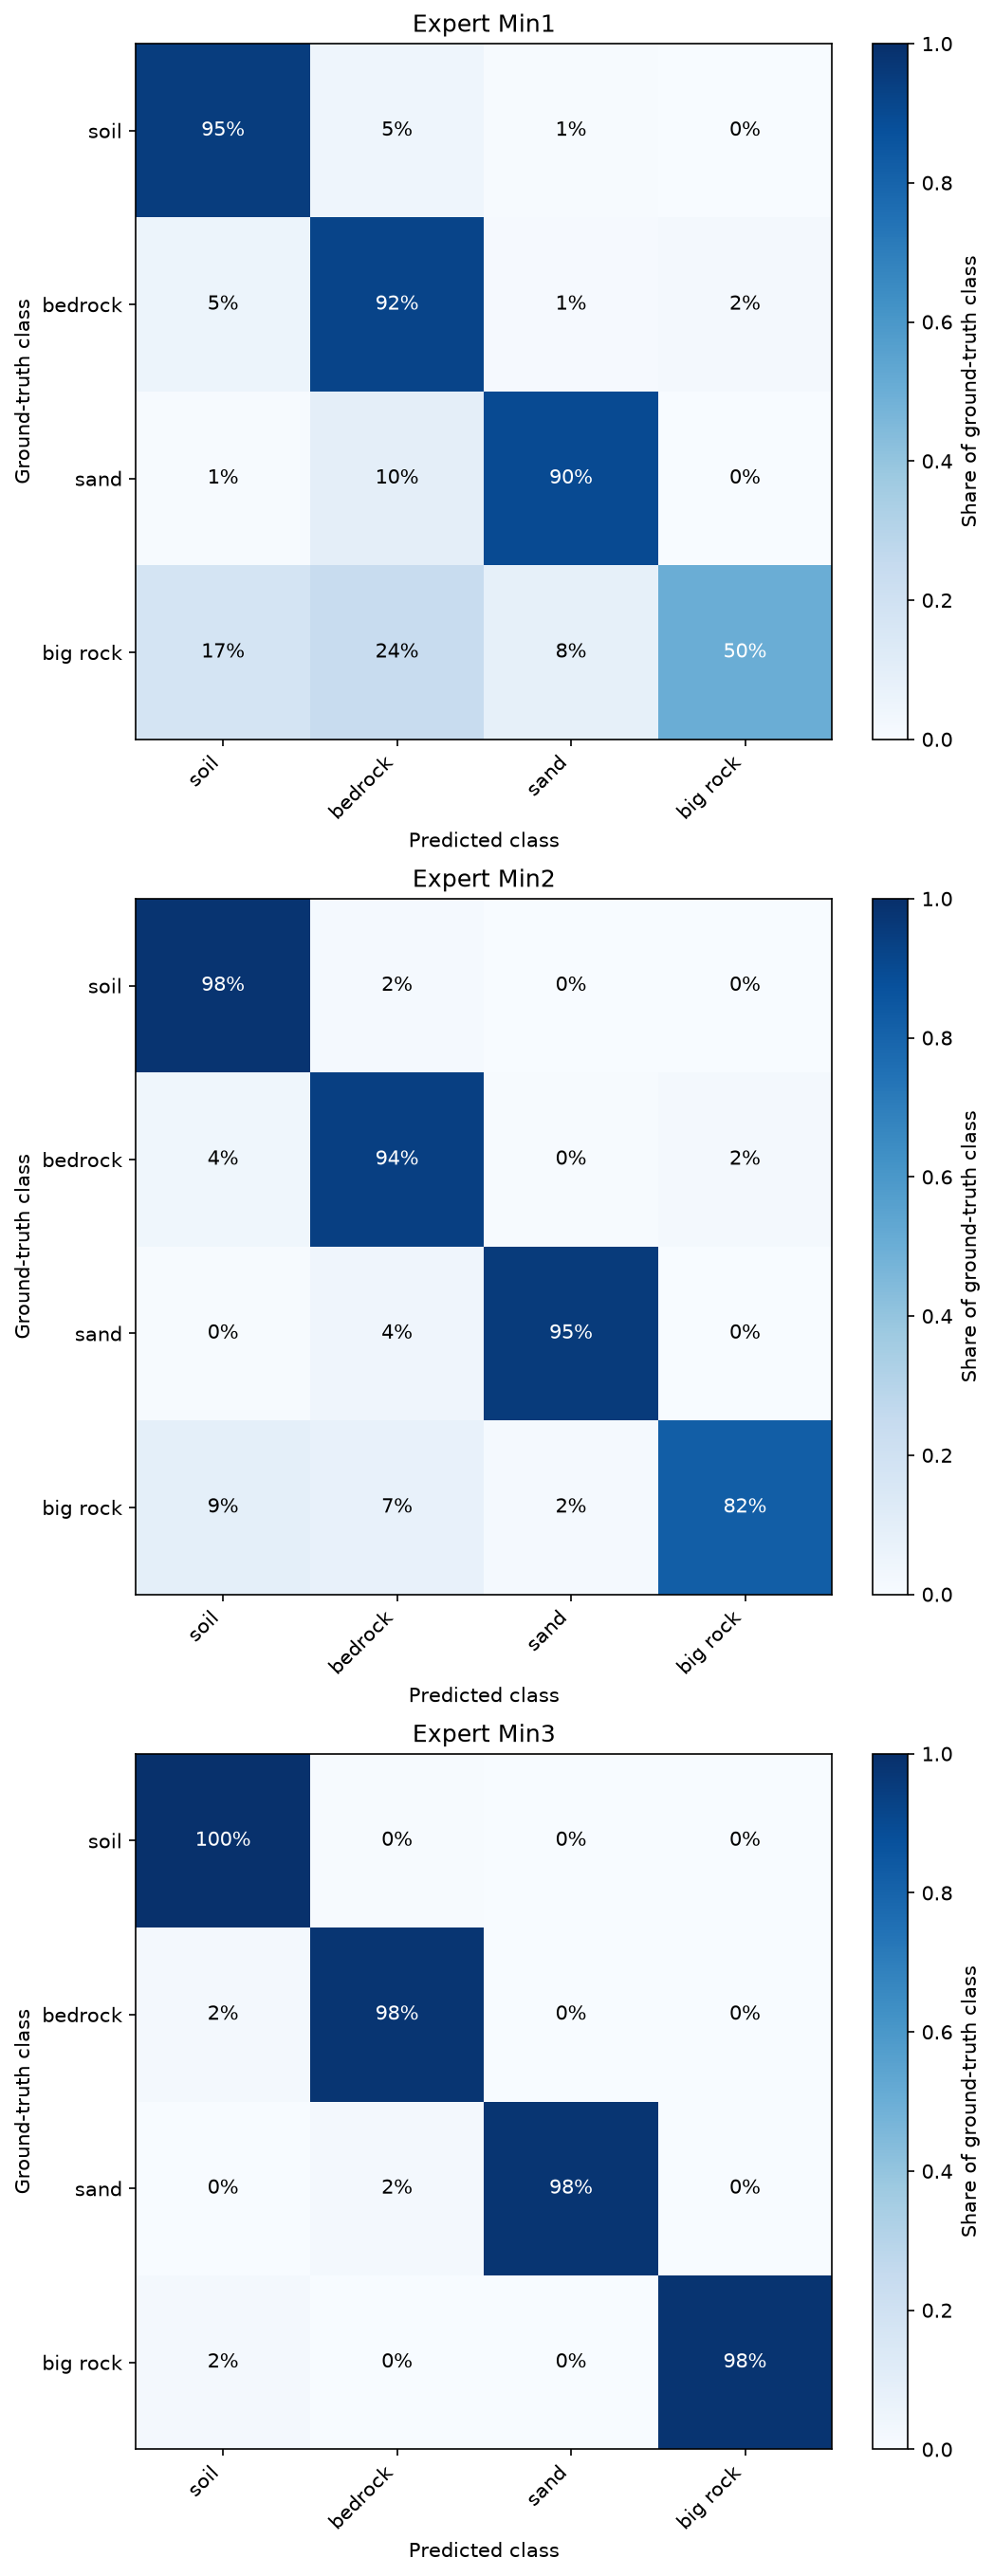

In [10]:
import base64
import json
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

report = json.loads((run_dir / 'artifacts' / 'expert_evaluation.json').read_text(encoding='utf-8'))
class_names = ('soil', 'bedrock', 'sand', 'big rock')
split_items = list(report['splits'].items())
figure, axes = plt.subplots(len(split_items), 1, figsize=(7, 18), constrained_layout=True)
axes = np.atleast_1d(axes)

for axis, (split_name, metrics) in zip(axes, split_items):
    matrix = np.asarray(metrics['normalized_confusion_matrix'], dtype=float)
    image = axis.imshow(matrix, vmin=0.0, vmax=1.0, cmap='Blues')
    axis.set_title(split_name.replace('_', ' ').title())
    axis.set_xlabel('Predicted class')
    axis.set_ylabel('Ground-truth class')
    axis.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    axis.set_yticks(range(len(class_names)), class_names)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            axis.text(column_index, row_index, f'{value:.0%}', ha='center', va='center', color='white' if value >= 0.5 else 'black')
    figure.colorbar(image, ax=axis, label='Share of ground-truth class')

image_buffer = BytesIO()
figure.savefig(image_buffer, format='png', dpi=150, bbox_inches='tight')
plt.close(figure)
display({'image/png': base64.b64encode(image_buffer.getvalue()).decode('ascii')}, raw=True)